#### Imports

In [86]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMClassifier, early_stopping
import optuna
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#### Starting Connection and Querying Data from Supabase

In [87]:
# Load environment variables from .env
load_dotenv()

# Fetch variables
USER = os.getenv("user")
PASSWORD = os.getenv("password")
HOST = os.getenv("host")
PORT = os.getenv("port")
DBNAME = os.getenv("dbname")

# Construct the SQLAlchemy connection string
DATABASE_URL = f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DBNAME}?sslmode=require"

# Create the SQLAlchemy engine
engine = create_engine(DATABASE_URL)
# If using Transaction Pooler or Session Pooler, we want to ensure we disable SQLAlchemy client side pooling -
# https://docs.sqlalchemy.org/en/20/core/pooling.html#switching-pool-implementations
# engine = create_engine(DATABASE_URL, poolclass=NullPool)

# Test the connection
try:
    with engine.connect() as connection:
        print("Connection successful!")
except Exception as e:
    print(f"Failed to connect: {e}")

Connection successful!


In [88]:
query = """
SELECT *
FROM "QBPointProjection"
WHERE season BETWEEN 2018 AND 2024
"""

qb_df = pd.read_sql(query, engine)

print(qb_df.shape)
qb_df.head()

(4305, 63)


,player_id,player_name,team,season,week,opponent_team,fantasy_points_ppr,attempts_prev,completions_prev,passing_yards_prev,...,rushing_fumbles_lost_roll5_mean,sack_fumbles_lost_lag1,sack_fumbles_lost_roll3_mean,sack_fumbles_lost_roll5_mean,pass_yards_allowed_roll3_mean,pass_yards_allowed_roll5_mean,pass_tds_allowed_roll3_mean,pass_tds_allowed_roll5_mean,qb_fp_allowed_roll3_mean,qb_fp_allowed_roll5_mean
0,00-0019596,T.Brady,NE,2018,1,HOU,21.28,581.0,385.0,4577.0,...,NaN,NaN,NaN,NaN,276.000000,259.00,2.500000,1.75,20.990000,18.835
1,00-0019596,T.Brady,NE,2018,2,JAX,16.36,581.0,385.0,4577.0,...,0.0,0.0,0.000000,0.000000,233.000000,216.25,1.000000,1.50,14.570000,14.525
2,00-0019596,T.Brady,NE,2018,3,DET,7.52,581.0,385.0,4577.0,...,0.0,1.0,0.500000,0.500000,202.000000,239.00,2.000000,1.50,15.230000,13.185
3,00-0019596,T.Brady,NE,2018,4,MIA,18.96,581.0,385.0,4577.0,...,0.0,0.0,0.333333,0.333333,299.666667,300.75,0.666667,0.75,10.453333,12.205
4,00-0019596,T.Brady,NE,2018,5,IND,27.54,581.0,385.0,4577.0,...,0.0,0.0,0.333333,0.250000,307.333333,291.25,1.000000,1.25,18.460000,17.975


In [89]:
qb_df['atleast10'] = qb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 10.0 else 0)
qb_df['atleast15'] = qb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 15.0 else 0)
qb_df['atleast20'] = qb_df['fantasy_points_ppr'].apply(lambda x: 1 if x >= 20.0 else 0)

#### 10 Point Probability Model

#### Building Feature and Target Set

In [90]:
TARGET = "atleast10"

keys_df = qb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast20", "atleast15", 'fantasy_points_ppr', TARGET]
X = qb_df.drop(columns=[c for c in drop_cols if c in qb_df.columns]).copy()
y = qb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (4305, 55) y shape: (4305,)


#### Building Training, Validation, and Test Set

In [91]:
train_mask = qb_df["season"].between(2018, 2022)
val_mask   = qb_df["season"].eq(2023)
test_mask  = qb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)

print(X_train.shape, X_val.shape, X_test.shape)

(3015, 55) (647, 55) (643, 55)


#### Finding Best Parameters

###### This function defines a set of model parameters. Then, a library called Optuna tests different combinations within specified ranges. For each trial, a LightGBM classifier is trained and evaluated using 5-fold cross-validation with ROC-AUC as the performance metric. The average ROC-AUC score across the folds is calculated to determine how well that parameter combination performed. The study runs optimization trials to search for the set of hyperparameters that maximizes the model’s ROC-AUC score. We picked ROC-AUC score as the metric to optimize on because it measures how well the model can distinguish between two classes.

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [93]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 2066, number of negative: 949
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5629
[LightGBM] [Info] Number of data points in the train set: 3015, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.685240 -> initscore=0.777961
[LightGBM] [Info] Start training from score 0.777961
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [94]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [95]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.732612055641422
Precision: 0.7188679245283018
Recall: 0.9407407407407408
F1 Score: 0.8149732620320855
ROC-AUC: 0.7450923375165799


Test Metrics
Accuracy: 0.7558320373250389
Precision: 0.7509363295880149
Recall: 0.9435294117647058
F1 Score: 0.8362877997914494
ROC-AUC: 0.762369131138694


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

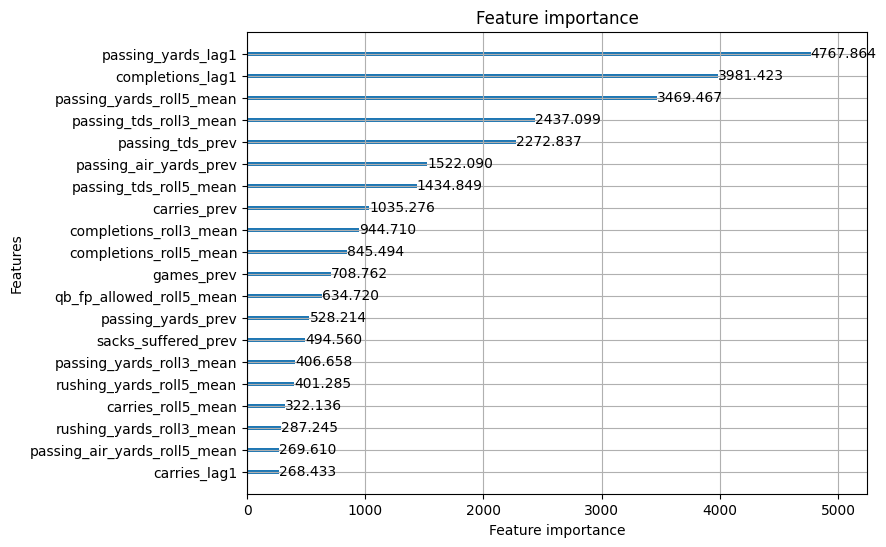

In [96]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [97]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast10"] = val_proba
val_preds_df["pred_atleast10"] = val_pred
val_preds_df["true_atleast10"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast10,pred_atleast10,true_atleast10
0,00-0023459,A.Rodgers,2023,1,NYJ,BUF,0.704078,1,0
1,00-0026158,J.Flacco,2023,13,CLE,LA,0.416290,0,1
2,00-0026158,J.Flacco,2023,14,CLE,JAX,0.697684,1,1
3,00-0026158,J.Flacco,2023,15,CLE,CHI,0.711983,1,1
4,00-0026158,J.Flacco,2023,16,CLE,HOU,0.699334,1,1
5,00-0026158,J.Flacco,2023,17,CLE,NYJ,0.658866,1,1
6,00-0026498,M.Stafford,2023,1,LA,SEA,0.542965,1,1
7,00-0026498,M.Stafford,2023,2,LA,SF,0.663226,1,1
8,00-0026498,M.Stafford,2023,3,LA,CIN,0.669222,1,1
9,00-0026498,M.Stafford,2023,4,LA,IND,0.713029,1,1


#### 15 Point Probability Model

#### Building Feature and Target Set

In [98]:
TARGET = "atleast15"

keys_df = qb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast20", 'fantasy_points_ppr', TARGET]
X = qb_df.drop(columns=[c for c in drop_cols if c in qb_df.columns]).copy()
y = qb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (4305, 55) y shape: (4305,)


#### Building Training, Validation, and Testing Set

In [99]:
train_mask = qb_df["season"].between(2018, 2022)
val_mask   = qb_df["season"].eq(2023)
test_mask  = qb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [101]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 1463, number of negative: 1552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5629
[LightGBM] [Info] Number of data points in the train set: 3015, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.485240 -> initscore=-0.059055
[LightGBM] [Info] Start training from score -0.059055
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [102]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.50
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [103]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.6506955177743431
Precision: 0.603112840466926
Recall: 0.5555555555555556
F1 Score: 0.5783582089552238
ROC-AUC: 0.6975173367617267


Test Metrics
Accuracy: 0.6267496111975117
Precision: 0.587360594795539
Recall: 0.5505226480836237
F1 Score: 0.5683453237410072
ROC-AUC: 0.6932623419332107


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

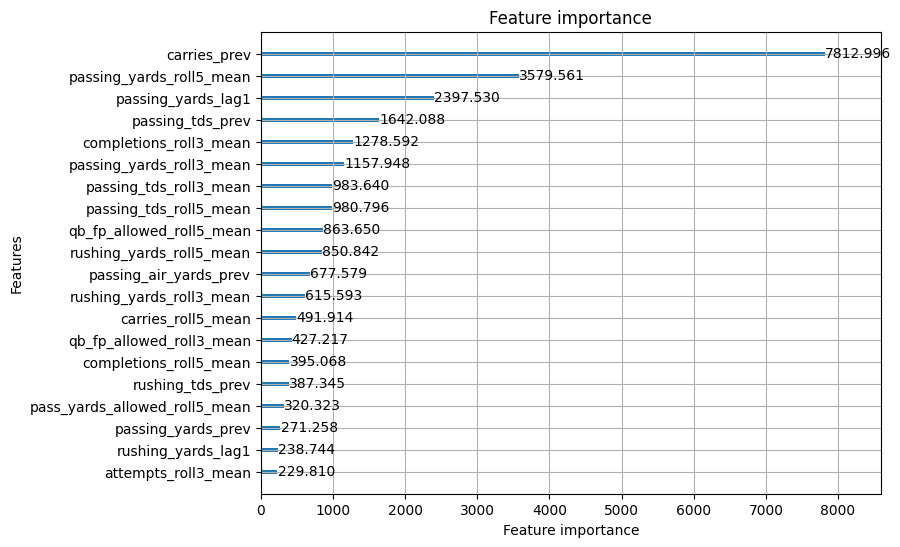

In [104]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [105]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast15"] = val_proba
val_preds_df["pred_atleast15"] = val_pred
val_preds_df["true_atleast15"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast15,pred_atleast15,true_atleast15
0,00-0023459,A.Rodgers,2023,1,NYJ,BUF,0.465078,0,0
1,00-0026158,J.Flacco,2023,13,CLE,LA,0.265807,0,1
2,00-0026158,J.Flacco,2023,14,CLE,JAX,0.470116,0,1
3,00-0026158,J.Flacco,2023,15,CLE,CHI,0.494736,0,1
4,00-0026158,J.Flacco,2023,16,CLE,HOU,0.516066,1,1
5,00-0026158,J.Flacco,2023,17,CLE,NYJ,0.487287,0,1
6,00-0026498,M.Stafford,2023,1,LA,SEA,0.305883,0,0
7,00-0026498,M.Stafford,2023,2,LA,SF,0.486697,0,0
8,00-0026498,M.Stafford,2023,3,LA,CIN,0.470914,0,0
9,00-0026498,M.Stafford,2023,4,LA,IND,0.509425,1,1


#### 20 Point Probability

#### Building Feature and Target Set

In [106]:
TARGET = "atleast20"

keys_df = qb_df[["player_id", "player_name", "season", "week", "team", "opponent_team"]].copy()

drop_cols = ["player_id", "player_name", "season", "week", "team", "opponent_team", "fantasy_points_ppr_prev", "atleast10", "atleast15", 'fantasy_points_ppr', TARGET]
X = qb_df.drop(columns=[c for c in drop_cols if c in qb_df.columns]).copy()
y = qb_df[TARGET].copy()

print("X shape:", X.shape, "y shape:", y.shape)

X shape: (4305, 55) y shape: (4305,)


#### Building Training, Validation, and Testing Set

In [107]:
train_mask = qb_df["season"].between(2018, 2022)
val_mask   = qb_df["season"].eq(2023)
test_mask  = qb_df["season"].eq(2024)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val,   y_val   = X.loc[val_mask],   y.loc[val_mask]
X_test,  y_test  = X.loc[test_mask],  y.loc[test_mask]

keys_train = keys_df.loc[train_mask].reset_index(drop=True)
keys_val   = keys_df.loc[val_mask].reset_index(drop=True)
keys_test  = keys_df.loc[test_mask].reset_index(drop=True)


#### Finding Best Parameters

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",
        "random_state": 42,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
    }

    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc"
    )

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25)

print("Best ROC-AUC:", study.best_value)
print("Best Parameters:", study.best_params)

#### Training Model

In [109]:
best_params = study.best_params

best_model = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    random_state=42,
    n_jobs=-1,
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],        
    eval_metric="binary_logloss",
    callbacks=[early_stopping(100, verbose=True)]
)

print("Best iteration:", best_model.best_iteration_)

[LightGBM] [Info] Number of positive: 836, number of negative: 2179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001246 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5629
[LightGBM] [Info] Number of data points in the train set: 3015, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.277280 -> initscore=-0.957993
[LightGBM] [Info] Start training from score -0.957993
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [110]:
val_proba  = best_model.predict_proba(X_val,  num_iteration=best_model.best_iteration_)[:, 1]
test_proba = best_model.predict_proba(X_test, num_iteration=best_model.best_iteration_)[:, 1]

thr = 0.3
val_pred = (val_proba >= thr).astype(int)
test_pred = (test_proba >= thr).astype(int)

#### Evaluating Model

In [111]:
def evaluate_model(y_true, y_pred, y_proba):

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))


print("Validation Metrics")
evaluate_model(y_val, val_pred, val_proba)
print("\n")
print("Test Metrics")
evaluate_model(y_test, test_pred, test_proba)

Validation Metrics
Accuracy: 0.6893353941267388
Precision: 0.3951219512195122
Recall: 0.5126582278481012
F1 Score: 0.4462809917355372
ROC-AUC: 0.6952900520307524


Test Metrics
Accuracy: 0.6702954898911353
Precision: 0.3920704845814978
Recall: 0.5460122699386503
F1 Score: 0.4564102564102564
ROC-AUC: 0.6953796012269938


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

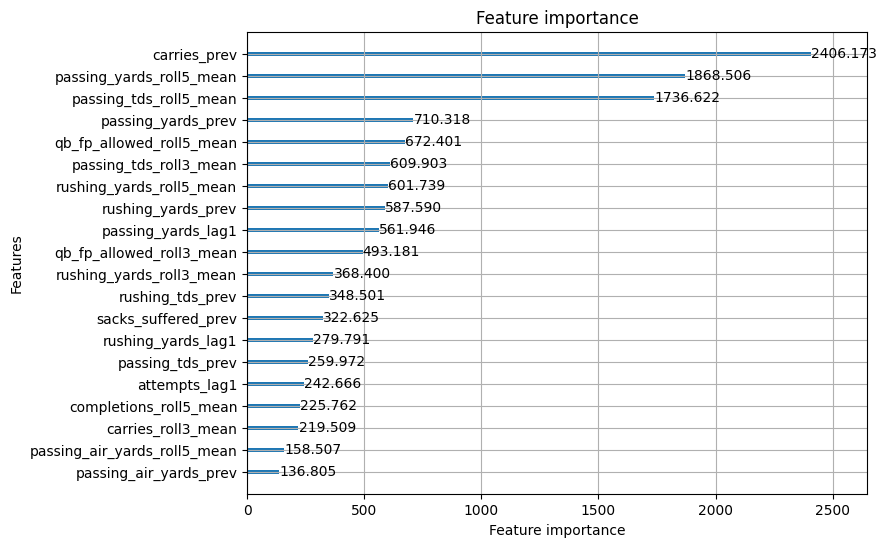

In [112]:
lgb.plot_importance(best_model, max_num_features=20, importance_type="gain", figsize=(8,6))

In [113]:
val_preds_df = keys_val.copy()
val_preds_df["proba_atleast20"] = val_proba
val_preds_df["pred_atleast20"] = val_pred
val_preds_df["true_atleast20"] = y_val.values
val_preds_df.head(20)

,player_id,player_name,season,week,team,opponent_team,proba_atleast20,pred_atleast20,true_atleast20
0,00-0023459,A.Rodgers,2023,1,NYJ,BUF,0.204894,0,0
1,00-0026158,J.Flacco,2023,13,CLE,LA,0.132972,0,0
2,00-0026158,J.Flacco,2023,14,CLE,JAX,0.297297,0,1
3,00-0026158,J.Flacco,2023,15,CLE,CHI,0.255998,0,0
4,00-0026158,J.Flacco,2023,16,CLE,HOU,0.315801,1,1
5,00-0026158,J.Flacco,2023,17,CLE,NYJ,0.255998,0,1
6,00-0026498,M.Stafford,2023,1,LA,SEA,0.130528,0,0
7,00-0026498,M.Stafford,2023,2,LA,SF,0.279477,0,0
8,00-0026498,M.Stafford,2023,3,LA,CIN,0.251894,0,0
9,00-0026498,M.Stafford,2023,4,LA,IND,0.240639,0,0
